# 02 · Cohérent ne veut pas dire calibré : MinT réconcilie des moyennes, pas des quantiles

**Bloc 4 · W37, notebook 2 sur 3.** C'est le cœur de la semaine : la phrase laissée ouverte en W36.

| § | Fait | Conséquence |
|---|---|---|
| 1 | Le quantile d'une somme n'est pas la somme des quantiles | Un « vecteur de quantiles cohérent » n'existe pas. |
| 2 | Appliquer $P$ à des quantiles donne un vecteur cohérent… et faux | **Méthode A** : fausse dans les deux sens. |
| 3 | Projeter des échantillons est la bonne mécanique… | **Méthode B** (tirages indépendants) : la pire. |
| 4 | … à condition qu'ils portent la dépendance | **Méthode C** (tirages joints) : calibrée partout. |
| 5 | Plus les séries sont corrélées, plus l'erreur « savante » coûte cher | Balayage en ρ. |
| 6 | En pratique : le **bootstrap joint** des résidus | Mêmes instants pour toutes les séries. |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.mint import mint_projection

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README et l'article (net en mode sombre)."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

## Le terrain d'expérience

Trois régions et leur total. Les feuilles sont gaussiennes, de moyennes (100, 60, 40) et d'écarts-types
(12, 9, 7), avec une **corrélation ρ = 0,6** entre régions (elles bougent ensemble, comme sous l'effet de la
météo). Tout est connu analytiquement : on peut donc comparer chaque méthode à la vérité.

Chaque série a son propre modèle de base, **parfait sur sa marginale**. Les moyennes sont déjà cohérentes, donc la
réconciliation des moyennes ne change rien. **Tout ce qu'on observe ici est un pur effet « quantile ».**

In [2]:
from w37_reconciliation.fundamentals.probabilistic import default_hierarchy, Z90, NAMES
h = default_hierarchy(rho=0.6)
display(pd.DataFrame({"moyenne": h.mu_y, "écart-type": h.sd_y, "quantile 90 % exact": h.exact_quantiles()}, index=NAMES))

,moyenne,écart-type,quantile 90 % exact
Total,200.0,24.083,230.864
Region_1,100.0,12.000,115.379
Region_2,60.0,9.000,71.534
Region_3,40.0,7.000,48.971


## 1. Le quantile d'une somme n'est pas la somme des quantiles

Additionner les quantiles à 90 % des trois régions revient à supposer qu'elles sont **toutes** dans leur pire 10 %
**en même temps**. Sauf si la corrélation vaut 1, c'est plus rare que 10 % du temps.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


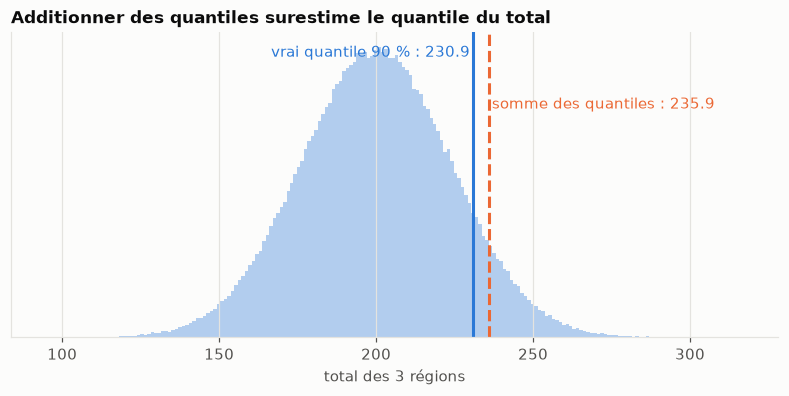

P(total ≤ somme des quantiles) = 0.931  (au lieu de 0,900)


In [3]:
rng = np.random.default_rng(0)
total = (h.mu_b + rng.normal(size=(400_000, 3)) @ np.linalg.cholesky(h.Sig_b).T).sum(axis=1)
sum_q, q_sum = (h.mu_b + Z90 * h.sd_b).sum(), np.quantile(total, 0.9)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(total, bins=200, density=True, color=viz.BLUE, alpha=0.35, edgecolor="none")
ax.axvline(q_sum, color=viz.BLUE, lw=2); ax.text(q_sum - 1, ax.get_ylim()[1] * 0.92, f"vrai quantile 90 % : {q_sum:.1f}",
                                               ha="right", color=viz.BLUE)
ax.axvline(sum_q, color=viz.ORANGE, lw=2, ls="--"); ax.text(sum_q + 1, ax.get_ylim()[1] * 0.75,
                                                           f"somme des quantiles : {sum_q:.1f}", color=viz.ORANGE)
ax.set_xlabel("total des 3 régions"); ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.set_title("Additionner des quantiles surestime le quantile du total")
export(fig, "quantile_somme"); plt.show()
print(f"P(total ≤ somme des quantiles) = {(total <= sum_q).mean():.3f}  (au lieu de 0,900)")

> 📌 **À retenir.** La cohérence est une propriété de la **loi jointe**, pas des marginales. « Des quantiles à 90 %
> qui somment » n'est pas un objet qui existe.

## 2. Méthode A : appliquer $P$ à des quantiles

C'est la faute la plus naturelle : on a des quantiles par série, on a $P$, et on multiplie.

In [4]:
P = h.projection()
qA = P @ h.exact_quantiles()
print("le vecteur A est-il cohérent ?  total − somme des régions =", round(qA[0] - qA[1:].sum(), 12))

le vecteur A est-il cohérent ?  total − somme des régions = 0.0


Il somme parfaitement, et il n'est **le quantile de rien**. Pour le montrer, on mesure sa **couverture** : la
proportion de réalisations qui tombent sous le seuil annoncé. Pour un quantile à 90 % correct, elle doit valoir
0,900.

## 3 & 4. Les trois méthodes face à la vérité

| Méthode | Ce qu'on fait |
|---|---|
| **A** | $P \times$ (vecteur des quantiles marginaux) |
| **B** | tirer 400 000 échantillons **indépendamment** pour chaque série, projeter chacun avec $P$, lire le quantile |
| **C** | tirer 400 000 échantillons **conjointement** (avec la covariance complète), projeter, lire le quantile |

C'est exactement le script du plan (graine 37), encapsulé dans `coverage_experiment`.

In [5]:
from w37_reconciliation.fundamentals import coverage_experiment
cov = coverage_experiment(rho=0.6)
display(cov.style.format("{:.3f}").format("{:.2f}", subset=["q_exact", "A: P@quantiles", "B: éch. indép.", "C: éch. dépendants"]))

,q_exact,A: P@quantiles,cov A,B: éch. indép.,cov B,C: éch. dépendants,cov C
Total,230.86,234.27,0.922,217.38,0.764,230.95,0.900
Region_1,115.38,114.53,0.887,113.98,0.878,115.41,0.900
Region_2,71.53,71.06,0.890,70.96,0.888,71.52,0.899
Region_3,48.97,48.68,0.893,48.70,0.894,48.99,0.901


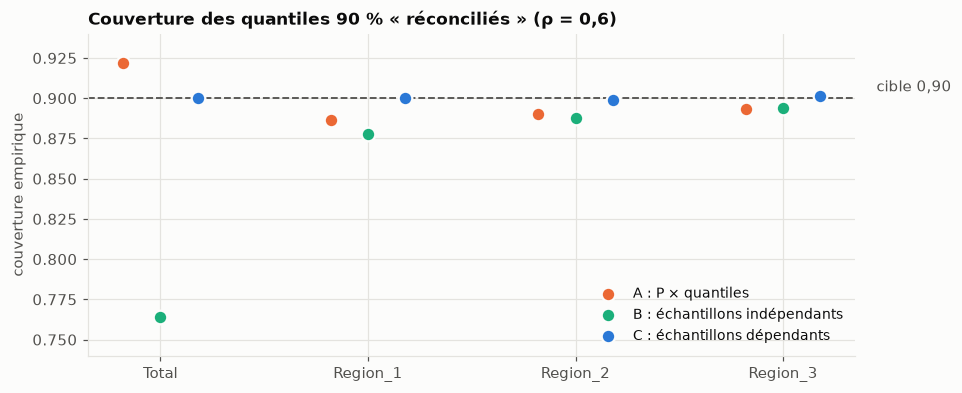

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(4)
for k, (col, name, color) in enumerate([("cov A", "A : P × quantiles", viz.ORANGE),
                                        ("cov B", "B : échantillons indépendants", viz.AQUA),
                                        ("cov C", "C : échantillons dépendants", viz.BLUE)]):
    ax.scatter(x + (k - 1) * 0.18, cov[col], s=80, color=color, label=name, zorder=3,
               edgecolor=viz.SURFACE, linewidth=1.5)
ax.axhline(0.9, color=viz.TEXT_2, lw=1.2, ls="--"); ax.text(3.45, 0.902, "cible 0,90", color=viz.TEXT_2, va="bottom")
ax.set_xticks(x, NAMES); ax.set_ylabel("couverture empirique"); ax.set_ylim(0.74, 0.94)
ax.set_title("Couverture des quantiles 90 % « réconciliés » (ρ = 0,6)")
ax.legend(loc="lower right", fontsize=9)
export(fig, "couverture_ABC"); plt.show()

**Lecture — les trois choses à retenir.**

1. **A sur-couvre au total (0,922) et sous-couvre les régions (≈ 0,89).** Elle est fausse **dans les deux sens à la
   fois** : aucun facteur global ne peut la corriger.
2. **B, qui a l'air correcte, est la pire : 0,764 au total pour 0,900 visé.** Projeter des échantillons est la bonne
   mécanique, mais des tirages indépendants n'ont pas de dépendance. La variance du total est sous-estimée.
3. **C atteint 0,900 à tous les niveaux.** Sa seule différence avec B est la structure de dépendance.

### 💡 Pourquoi B échoue : la variance du total

In [7]:
rng = np.random.default_rng(1)
N = 200_000
draws_B = (h.mu_y + rng.normal(size=(N, 4)) * h.sd_y) @ P.T
draws_C = (h.mu_y + rng.normal(size=(N, 4)) @ np.linalg.cholesky(h.Sig_y + 1e-9 * np.eye(4)).T) @ P.T
display(pd.DataFrame({"vraie loi": h.sd_y, "B (indépendant)": draws_B.std(0), "C (joint)": draws_C.std(0)},
                     index=NAMES).style.format("{:.2f}").set_caption("écart-type des prévisions réconciliées"))

,vraie loi,B (indépendant),C (joint)
Total,24.08,13.61,24.03
Region_1,12.00,10.92,11.96
Region_2,9.00,8.55,9.00
Region_3,7.00,6.79,6.98


Le total réconcilié par B a un écart-type d'environ 17, contre 24 en réalité : **le risque agrégé est sous-estimé
d'un tiers.** C'est exactement le stock de sécurité national sous-dimensionné, ou la réserve de capacité réseau
insuffisante.

> ⚠️ **Point d'attention — même avec des régions indépendantes, B échoue.** Avec ρ = 0, la couverture de B au
> total vaut encore 0,816 (§ 5). La dépendance n'est pas seulement *entre régions* : l'erreur du **total** est
> structurellement liée à celles des **régions**, puisque le total en est la somme. Un pipeline par série la perd
> toujours.

## 5. Le balayage qui rend le résultat non discutable

In [8]:
from w37_reconciliation.fundamentals import rho_sweep
sw = rho_sweep(rhos=(0.0, 0.3, 0.6, 0.9))
display(sw.style.format({"rho": "{:.1f}", "somme des quantiles 90 %": "{:.2f}", "quantile 90 % de la somme": "{:.2f}",
                         "écart": "{:+.1%}", "couverture B (total)": "{:.3f}", "couverture C (total)": "{:.3f}"}))

,rho,somme des quantiles 90 %,quantile 90 % de la somme,écart,couverture B (total),couverture C (total)
0,0.0,235.88,221.21,+6.6%,0.816,0.901
1,0.3,235.88,226.48,+4.2%,0.787,0.901
2,0.6,235.88,230.86,+2.2%,0.764,0.900
3,0.9,235.88,234.70,+0.5%,0.746,0.900


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


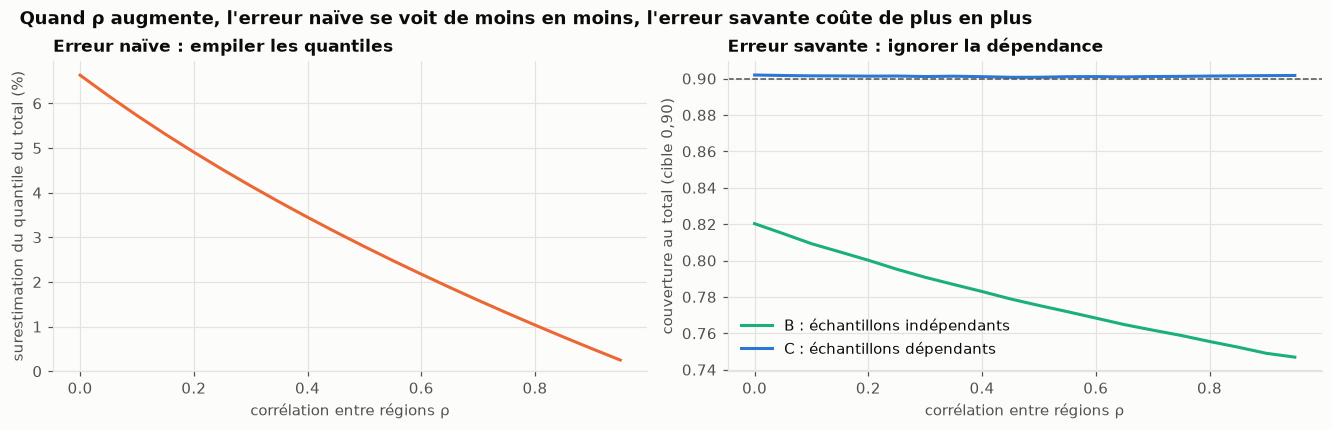

In [9]:
sw_fine = rho_sweep(rhos=np.round(np.linspace(0, 0.95, 20), 3), n=150_000)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
axs[0].plot(sw_fine["rho"], sw_fine["écart"] * 100, color=viz.ORANGE)
axs[0].set_title("Erreur naïve : empiler les quantiles"); axs[0].set_ylabel("surestimation du quantile du total (%)")
axs[0].set_ylim(0, None)
axs[1].plot(sw_fine["rho"], sw_fine["couverture B (total)"], color=viz.AQUA, label="B : échantillons indépendants")
axs[1].plot(sw_fine["rho"], sw_fine["couverture C (total)"], color=viz.BLUE, label="C : échantillons dépendants")
axs[1].axhline(0.9, color=viz.TEXT_2, ls="--", lw=1)
axs[1].set_title("Erreur savante : ignorer la dépendance"); axs[1].set_ylabel("couverture au total (cible 0,90)")
axs[1].legend(loc="lower left")
for ax in axs: ax.set_xlabel("corrélation entre régions ρ")
fig.suptitle("Quand ρ augmente, l'erreur naïve se voit de moins en moins, l'erreur savante coûte de plus en plus",
             x=0.01, ha="left", fontweight="semibold")
export(fig, "rho_balayage"); plt.show()

> 💡 **Le fait contre-intuitif à garder pour l'article.** Les deux erreurs vont **en sens opposé** quand la
> corrélation augmente. Empiler les quantiles devient de moins en moins faux (+6,6 % → +0,5 %), tandis qu'ignorer la
> dépendance devient de plus en plus faux (0,816 → 0,746). **Plus vos séries sont corrélées, moins l'erreur naïve se
> voit, et plus l'erreur savante coûte cher.** C'est exactement le régime de l'énergie et du retail promotionnel.

> ⚠️ **Petite correction du plan.** Le tableau de balayage du plan indique une couverture de B de 0,766 pour
> ρ = 0,6. Son propre script, et ce notebook, donnent **0,764**, la valeur de son tableau principal.

## 6. En pratique : le bootstrap **joint** des résidus

Dans la vraie vie, on ne connaît pas $\Sigma_y$. On dispose en revanche des **résidus in-sample** de chaque série
(bloc 2), alignés dans le temps. La méthode C s'obtient en tirant des **instants** :

```
résidus in-sample E (T × m)            bootstrap JOINT                bootstrap INDÉPENDANT
        Tot   R1    R2    R3           on tire des lignes entières     on tire chaque colonne séparément
t=1   [ e11  e12   e13   e14 ]  ──▶   [ e31 e32 e33 e34 ]              [ e51 e22 e83 e14 ]
t=2   [ e21  e22   e23   e24 ]        [ e71 e72 e73 e74 ]              [ e11 e92 e43 e64 ]
 …                                    la dépendance est conservée       la dépendance est détruite
```

,q bootstrap joint,cov bootstrap joint,q bootstrap indépendant,cov bootstrap indépendant
Total,231.137,0.902,216.983,0.760
Region_1,115.264,0.899,113.719,0.874
Region_2,72.049,0.910,70.796,0.885
Region_3,49.231,0.907,48.686,0.893


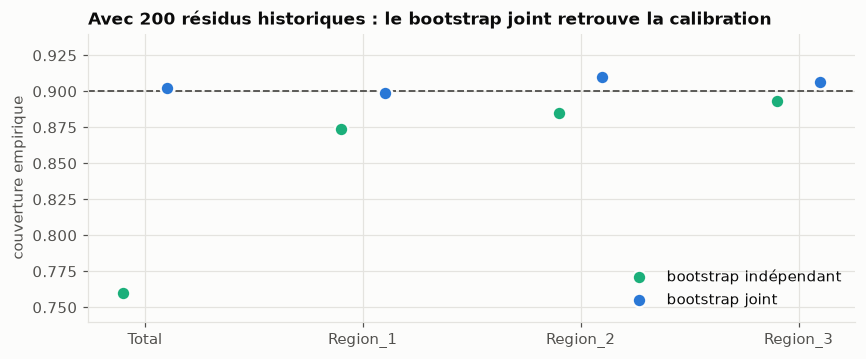

In [10]:
from w37_reconciliation.fundamentals import bootstrap_coverage
bs = bootstrap_coverage(rho=0.6, T=200)
display(bs.style.format("{:.3f}"))
fig, ax = plt.subplots(figsize=(9, 3.4))
for k, (col, name, color) in enumerate([("cov bootstrap indépendant", "bootstrap indépendant", viz.AQUA),
                                        ("cov bootstrap joint", "bootstrap joint", viz.BLUE)]):
    ax.scatter(np.arange(4) + (k - 0.5) * 0.2, bs[col], s=80, color=color, label=name, zorder=3,
               edgecolor=viz.SURFACE, linewidth=1.5)
ax.axhline(0.9, color=viz.TEXT_2, ls="--", lw=1.2)
ax.set_xticks(range(4), NAMES); ax.set_ylim(0.74, 0.94); ax.set_ylabel("couverture empirique")
ax.set_title("Avec 200 résidus historiques : le bootstrap joint retrouve la calibration")
ax.legend(loc="lower right")
export(fig, "bootstrap_joint"); plt.show()

Avec seulement 200 résidus, le bootstrap joint couvre ≈ 0,90 partout, aux fluctuations d'échantillonnage près. Le
bootstrap indépendant reproduit l'échec de la méthode B (≈ 0,76 au total).

**Dans `HierarchicalForecast`**, c'est le paramètre `intervals_method` de `HierarchicalReconciliation.reconcile` :

```python
hrec.reconcile(Y_hat_df=Y_hat, Y_df=Y_fit, S_df=S_df, tags=tags,
               level=[80, 90], intervals_method="bootstrap", num_samples=1000, seed=0)
# "normality" : gaussien, à partir de W ; "bootstrap" : rééchantillonnage des résidus ;
# "permbu" : reconstruction de la dépendance par permutations, du bas vers le haut
```

> ⚠️ **Point d'attention — vérifier ce qu'on rééchantillonne.** Un bootstrap qui tire chaque série
> indépendamment, ou des résidus pris à des dates différentes selon les séries (historiques de longueurs
> différentes, trous), est une méthode B déguisée. **Même instant, toutes les séries** : c'est la seule règle.

> 📌 **À retenir — le probabiliste.**
> - Ne **jamais** appliquer $P$ à des quantiles (méthode A) : cohérent, faux dans les deux sens.
> - Réconcilier une distribution = **projeter des échantillons joints**, puis lire les quantiles (méthode C).
> - Des échantillons indépendants (méthode B) sous-estiment le risque agrégé : 0,764 au lieu de 0,900.
> - En pratique : **bootstrap joint des résidus in-sample**, mêmes instants pour toutes les séries.
> - Plus les séries sont corrélées, plus ignorer la dépendance coûte cher.

→ Notebook **03** : le mur numérique, et la question d'entretien.